<h1><center> TP d’Initiation au Traitement du Signal </center></h1>

<h2><center>Consignes</center></h2>
 
1. Le fichier .ipynb doit être enregistré sous la forme: *votre_Nom_Prenom.ipynb* et être déposé sous Moodle.
1.Chacune de vos réponses aux questions doit avoir un code source et des résultats numériques ou des images et/ou bien des commentaires associés.
***

<h3><center>EXERCICE 1 : ÉCHANTILLONNAGE</center></h3>

On considère le signal analogique $y(t) = cos(2πf0t)$ avec $t$ $∈$ $R$, et $f0 = 3kHz$. On échantillonne $y(t)$ à la fréquence $fe$.
Soit $ye(n)$ le signal ainsi échantillonné.

1) On fixe $fe = 10kHz$. Représenter le signal temporel et le module de sa transformée de Fourier sur deux figures différentes.

$ye(n)=cos(2πf0nTe)$

$Te = 1/fe = 1/10000 = 0.0001s$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

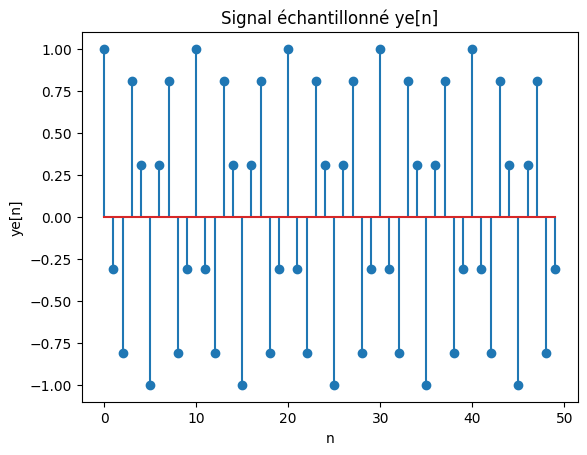

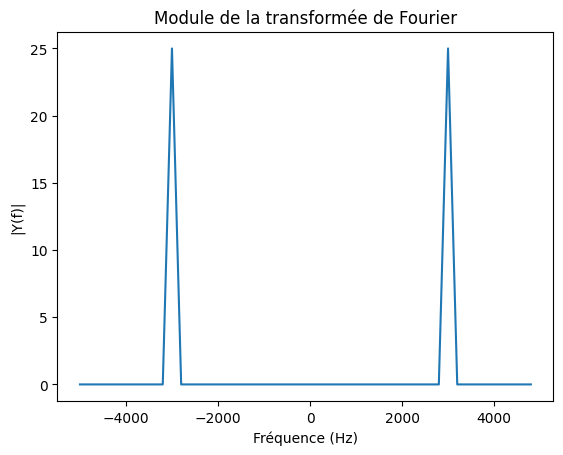

In [2]:
f0=3000
fe=10000
Te=1/fe
n = np.arange(0, 50)
ye=np.cos(2*np.pi*f0*n*Te)

plt.figure()
plt.stem(n, ye)
plt.xlabel("n")
plt.ylabel("ye[n]")
plt.title("Signal échantillonné ye[n]")
plt.show()

Y = np.fft.fftshift(np.fft.fft(ye))
freq = np.fft.fftshift(np.fft.fftfreq(len(ye), d=1/fe))


plt.figure()
plt.plot(freq, np.abs(Y))
plt.xlabel("Fréquence (Hz)")
plt.ylabel("|Y(f)|")
plt.title("Module de la transformée de Fourier")
plt.show()

2) On fixe $fe = 4kHz$. Représenter le signal temporel et le module de sa transformée de Fourier sur deux figures différentes. Conclure.

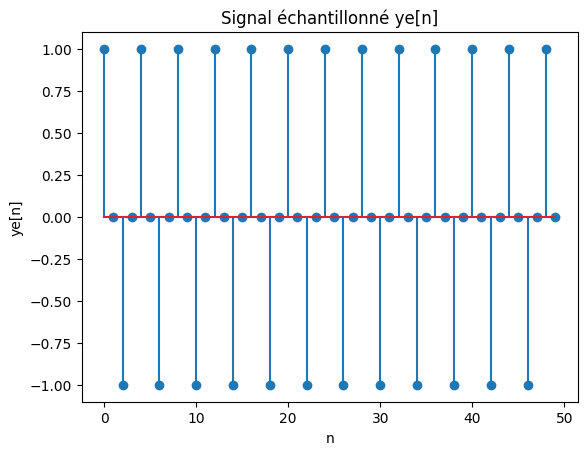

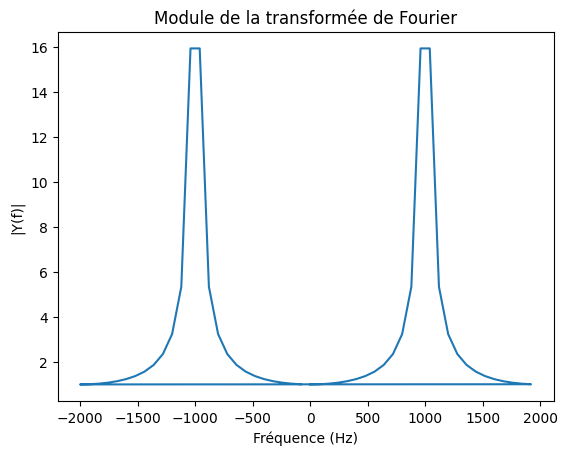

In [3]:
fe=4000
Te=1/fe
ye=np.cos(2*np.pi*f0*n*Te)

plt.figure()
plt.stem(n, ye)
plt.xlabel("n")
plt.ylabel("ye[n]")
plt.title("Signal échantillonné ye[n]")
plt.show()

Y = np.fft.fft(ye)
freq = np.fft.fftfreq(len(ye), d=1/fe)

plt.figure()
plt.plot(freq, np.abs(Y))
plt.xlabel("Fréquence (Hz)")
plt.ylabel("|Y(f)|")
plt.title("Module de la transformée de Fourier")
plt.show()


*Commentaires (fréquence d'échantillonnage)*: Il y a repliement de spectre (aliasing) car la fréquence d’échantillonnage est inférieure à deux fois la fréquence du signal (fe < 2f0). Le signal reconstruit est donc déformé.

3) Charger, à l’aide de scipy.io.wavfile, le son "handel" qui a été échantillonné à la fréquence d’échantillonnage $fe = 8192Hz$ et quantifié sur 16 bits.

In [4]:
import scipy.io.wavfile as wav 
fs, signal = wav.read('handel.wav')
print(fs)
print(signal.dtype)

8192
int16


4) Sous-échantillonner le signal sonore précédent d’un facteur 2 et écoutez-le. Conclure sur les effets du sous-échantionllonnage.

In [5]:
signal_sub = signal[::2]
fn = fs // 2

wav.write('handel_sub2.wav', fn, signal_sub)

*Commentaires (effets du sous-échantionllonnage)*: Le sous-échantillonnage réduit la fréquence d’échantillonnage, ce qui provoque un repliement de spectre (aliasing). Cela dégrade fortement la qualité du signal audio.

5) Sur-échantillonner le signal sonore précédent d’un facteur 2 et écoutez-le. Conclure sur les effets du sur-échantionllonnage.

In [6]:
signal_up = np.zeros(len(signal)*2, dtype=signal.dtype)
signal_up[::2] = signal

fn = fs * 2

wav.write('handel_up2.wav', fn, signal_up)

*Commentaires (effets du sur-échantionllonnage)*: Le sur-échantillonnage par insertion de zéros n’améliore pas la qualité du signal et peut introduire des artefacts. Un filtrage passe-bas est nécessaire pour reconstruire correctement le signal.

***

<h3><center>EXERCICE 2 : TRANSFORMÉE DE FOURIER ET FILTRAGE</center></h3>

Soit le signal $x(n) = (1/2)^n$  $u(n)$, avec $u(n)$ l’échelon unité. 

1) Calculer $X(f)$ la transformée de Fourier de $x(n)$, avec $n = −128, ..., −1, 0, 1, 2, ..., 128$. Représenter le module et la phase de $X(f)$. On rappelle que $f$ $∈$ $[$−1/2$,  $1/2$]$



257


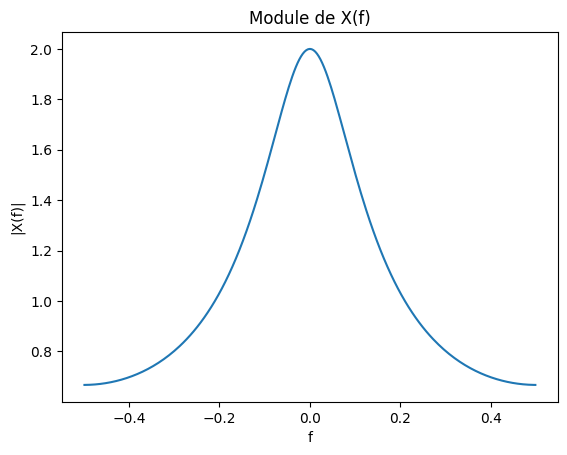

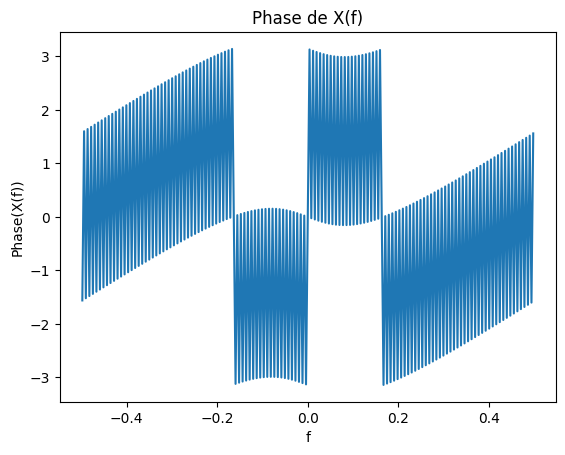

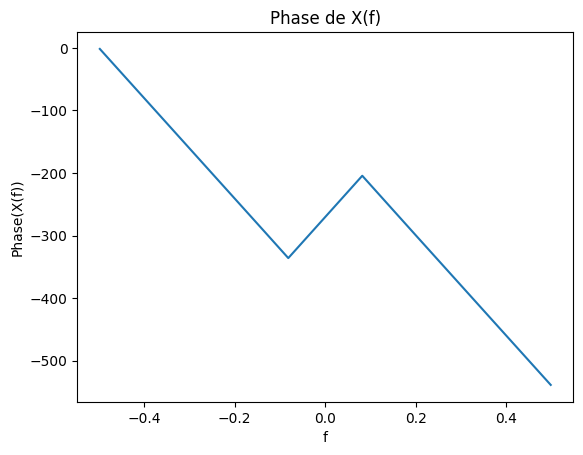

In [7]:
n = np.arange(-128,129)

x = (0.5)**n * (n >= 0)

X = np.fft.fftshift(np.fft.fft(x))

N = len(x)
f = np.fft.fftshift(np.fft.fftfreq(N, d=1))
print(N)

plt.figure()
plt.plot(f, np.abs(X))
plt.xlabel("f")
plt.ylabel("|X(f)|")
plt.title("Module de X(f)")
plt.show()

plt.figure()
plt.plot(f, np.angle(X))
plt.xlabel("f")
plt.ylabel("Phase(X(f))")
plt.title("Phase de X(f)")
plt.show()

plt.figure()
plt.plot(f, np.unwrap(np.angle(X)))
plt.xlabel("f")
plt.ylabel("Phase(X(f))")
plt.title("Phase de X(f)")
plt.show()

2) Quelle est la nature (passe-haut, bas, bande) de ce filtre?

*Commentaires*: C'est un filtre passe bas

3) On considère un filtre passe-bas idéal de fréquence de coupure 1/4. Représenter le module (dans le domaine de Fourier) de ce filtre.


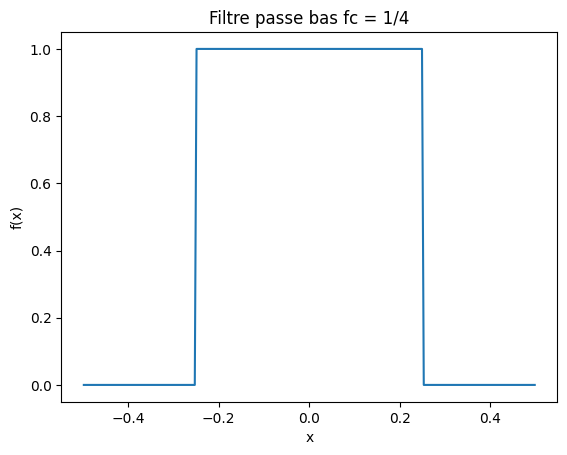

In [8]:
fc = 1/4

fpb = np.where(np.abs(f)<= fc,1,0)


plt.figure()
plt.plot(f, fpb)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Filtre passe bas fc = 1/4")
plt.show()



Soit $y(n) = cos(2πf1n)+cos(2πf2n)+cos(2πf3n)$, avec $n = −128, ..., −1, 0, 1, 2, ..., 128$ et $f1 = 1/5$, $f2 = 1/3$, $f3 = 2/5$.

4) Représenter y(n).

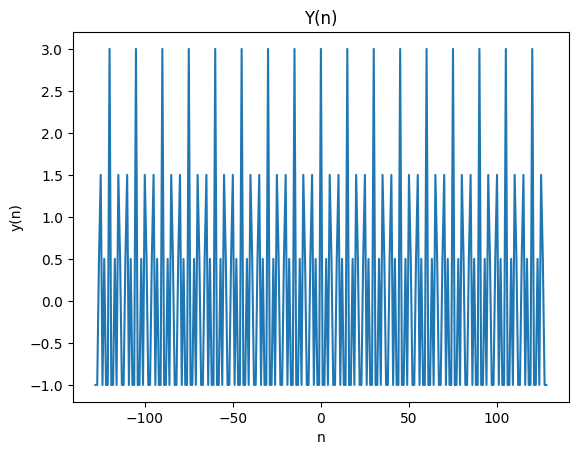

In [9]:
f1=1/5
f2=1/3
f3=2/5
y= np.cos(2*np.pi*f1*n)+np.cos(2*np.pi*f2*n)+np.cos(2*np.pi*f3*n)
plt.figure()
plt.plot(n, y)
plt.xlabel("n")
plt.ylabel("y(n)")
plt.title("Y(n)")
plt.show()

5) Quelle est la fréquence d’échantillonnage à laquelle est échantillonné le signal $y(n)$ ?

*Commentaires*: Le signal est discret, donc la fréquence d’échantillonnage est implicite et normalisée à fe = 1.

6) On souhaite éliminer les fréquences $f2$ et $f3$.
Donner la nature et la fréquence de coupure du filtre à utiliser.

*Commentaires*: Il faut un filtre passe-bas de fréquence de coupure fc = 1/4 pour conserver uniquement f1 et éliminer f2 et f3.

7) Réaliser le filtrage. Afficher le signal filtré temporel et sa transformée de Fourier sur deux figures différentes. Conclure.

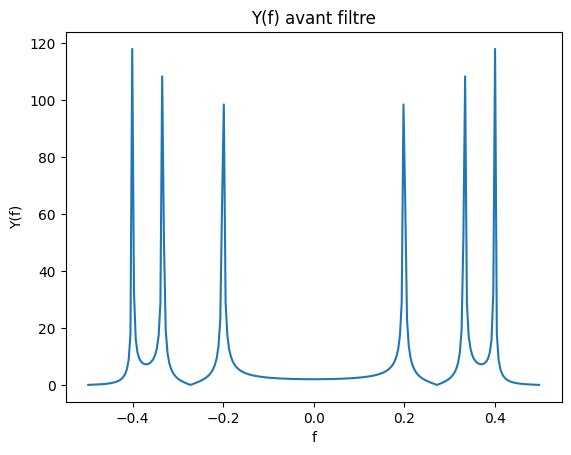

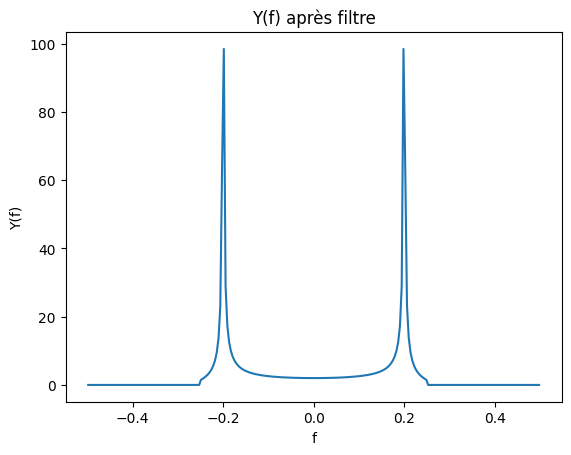

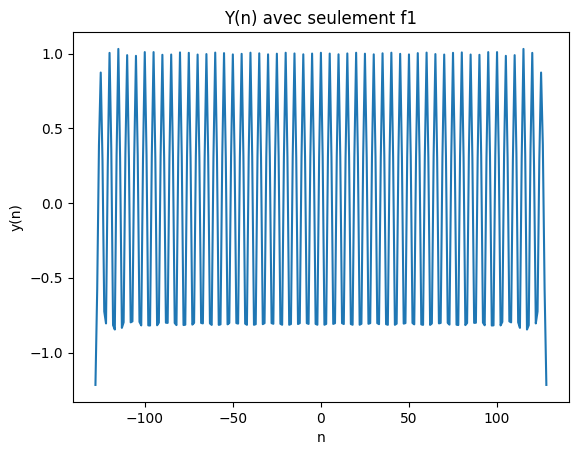

In [10]:
Yf = np.fft.fftshift(np.fft.fft(y))
f = np.fft.fftshift(np.fft.fftfreq(N, d=1))
YFpb1 = Yf*fpb
plt.figure()
plt.plot(f, np.abs(Yf))
plt.xlabel("f")
plt.ylabel("Y(f)")
plt.title("Y(f) avant filtre")
plt.show()

plt.figure()
plt.plot(f, np.abs(YFpb1))
plt.xlabel("f")
plt.ylabel("Y(f)")
plt.title("Y(f) après filtre")
plt.show()

yf1 = np.fft.ifft(np.fft.ifftshift(YFpb1))

plt.figure()
plt.plot(n, np.real(yf1))
plt.xlabel("n")
plt.ylabel("y(n)")
plt.title("Y(n) avec seulement f1")
plt.show()

*Commentaires*: Le filtre passe-bas permet de conserver uniquement la composante basse fréquence f1. Les composantes f2 et f3 sont supprimées, ce qui est visible dans le spectre et le signal temporel.

8) Comment modifier le filtre passe-bas idéal pour éliminer $f1$ ?

*Commentaires*: on inverse le signe pour le transformer en filtre passe haut. (>= à la place de <=)

9) Réaliser le filtrage. Afficher le signal filtré temporel et sa transformée de Fourier sur deux figures différentes. Conclure.

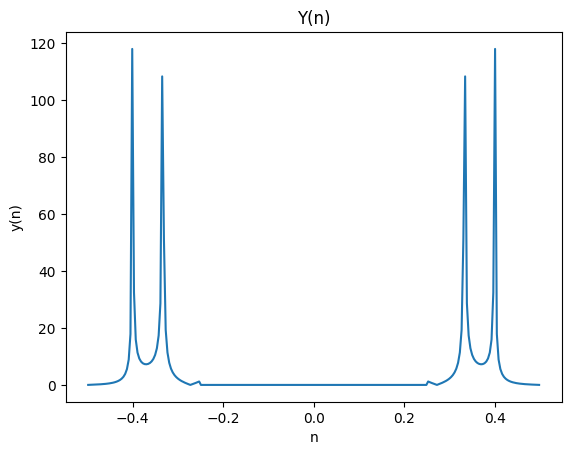

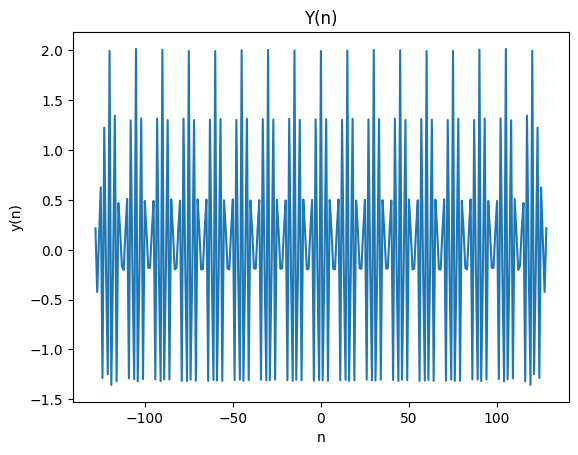

In [15]:
fcb = np.where(np.abs(f) >= fc, 1, 0)
Yfcb = Yf*fcb

plt.figure()
plt.plot(f, np.abs(Yfcb))
plt.xlabel("n")
plt.ylabel("y(n)")
plt.title("Y(n)")
plt.show()

yfcb = np.fft.ifft(np.fft.ifftshift(Yfcb))

plt.figure()
plt.plot(n, np.real(yfcb))
plt.xlabel("n")
plt.ylabel("y(n)")
plt.title("Y(n)")
plt.show()

*Commentaires*: Après filtrage, seules les composantes fréquentielles f2 et f3 sont conservées, ce qui est visible sur le spectre.

***

<h3><center>EXERCICE 3 : FILTRAGE D’UN SIGNAL SONORE</center></h3>

Charger, à l’aide de scipy.io.wavfile, le son "handel" qui a été échantillonné à la fréquence d’échantillonnage $fe = 8192Hz$ et quantifié sur 16 bits.

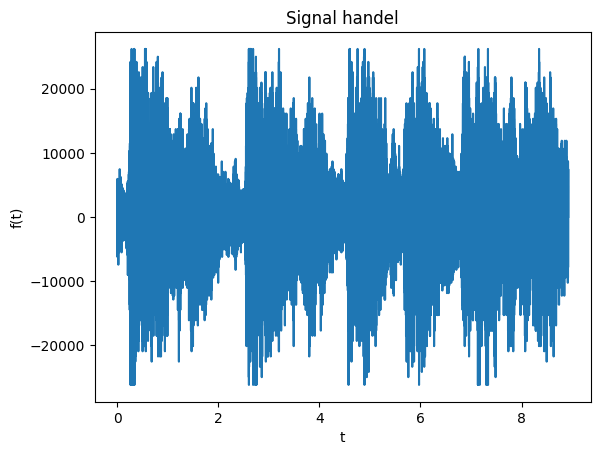

In [16]:
fs2, signal2 = wav.read('handel.wav')
t = np.arange(len(signal2)) / fs2 
plt.figure()
plt.plot(t, signal2)
plt.xlabel("t")
plt.ylabel("f(t)")
plt.title("Signal handel")
plt.show()


1) Quelle est la durée en secondes de ce signal sonore ?

*Commentaires*: La durée du signal est donnée par N/fe ≈ 8.92 secondes.

2) Calculer et afficher le module de la transformée de Fourier de ce signal sonore.

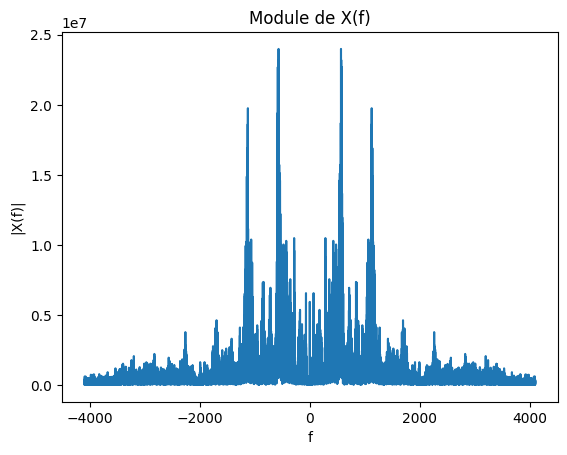

In [17]:
X = np.fft.fftshift(np.fft.fft(signal2))

N = len(signal2)
f = np.fft.fftshift(np.fft.fftfreq(N, d=1/fs2))

plt.figure()
plt.plot(f, np.abs(X))
plt.xlabel("f")
plt.ylabel("|X(f)|")
plt.title("Module de X(f)")
plt.show()

3) Générer un signal sinusoïdal, de fréquence 3 kHz, échantillonné à $fe = 8192Hz$, et de la même durée que le signal sonore "handel".

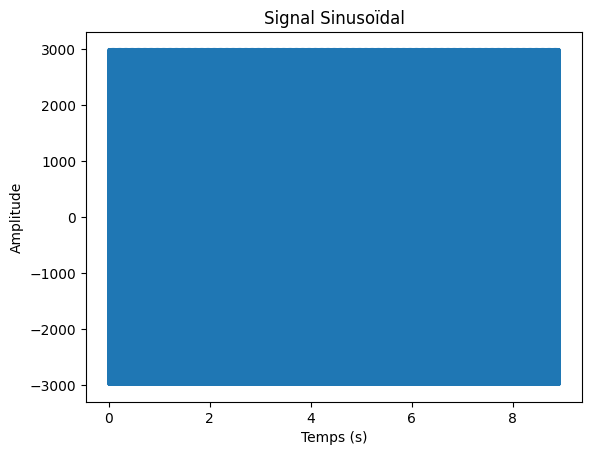

In [18]:
fe = fs2
f = 3000
A = 3000
N = len(signal2)
t = np.arange(N) / fe 
sin = A * np.sin(2 * np.pi * f * t)
plt.figure()
plt.plot(t, sin)
plt.xlabel("Temps (s)")
plt.ylabel("Amplitude")
plt.title("Signal Sinusoïdal")
plt.show()

4) Additionner ce signal sinusoïdal au signal handel et écouter le signal résultant.

In [19]:
signal_sin = signal2 + sin
signal_sin = np.clip(signal_sin, -32768, 32767)

wav.write('handel_sin.wav', fs2, signal_sin.astype(np.int16))

5) Calculer et afficher le module de la transformée de Fourier du signal résultant.

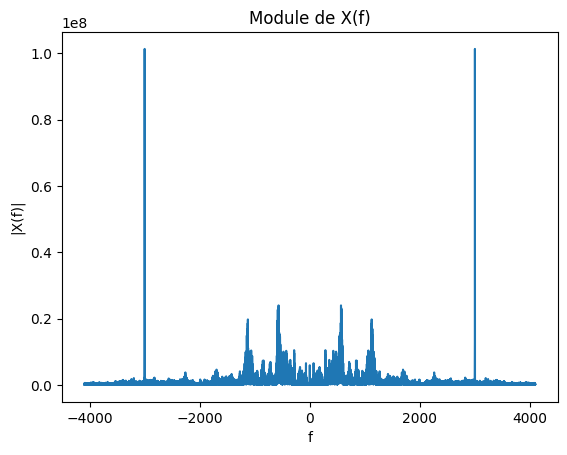

In [20]:

Ysin = np.fft.fftshift(np.fft.fft(signal_sin))

N = len(signal_sin)
f = np.fft.fftshift(np.fft.fftfreq(N, d=1/fs2))

plt.figure()
plt.plot(f, np.abs(Ysin))
plt.xlabel("f")
plt.ylabel("|X(f)|")
plt.title("Module de X(f)")
plt.show()

6) Proposer une méthode pour filtrer le signal cosinus. Mettez-la en oeuvre et écouter le signal filtré.

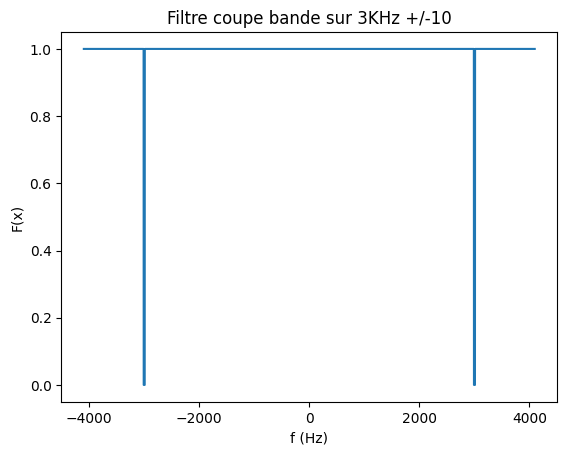

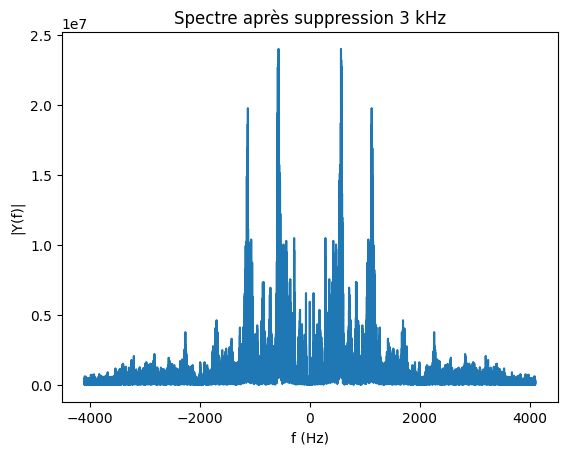

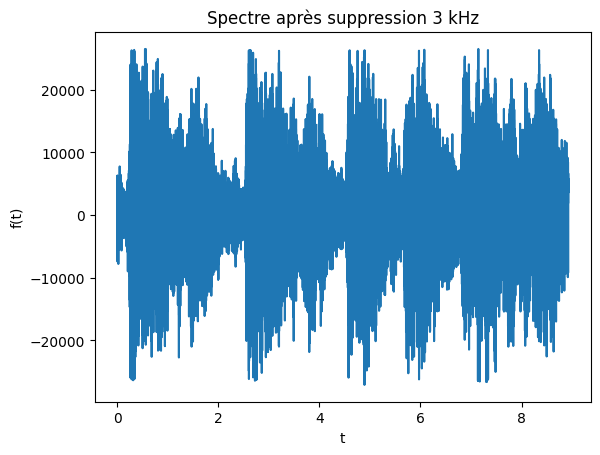

In [21]:
filtre = []
bande=3000
ecart=10
for i in f:
    if (bande-ecart <= i and i <= bande+ecart) or (-bande-ecart <= i and i <= -bande+ecart):
        filtre.append(0)
    else:
        filtre.append(1)

plt.figure()
plt.plot(f, filtre)
plt.xlabel("f (Hz)")
plt.ylabel("F(x)")
plt.title("Filtre coupe bande sur 3KHz +/-10")
plt.show()

Ycp = Ysin * filtre
ycp = np.fft.ifft(np.fft.ifftshift(Ycp))

plt.figure()
plt.plot(f, np.abs(Ycp))
plt.xlabel("f (Hz)")
plt.ylabel("|Y(f)|")
plt.title("Spectre après suppression 3 kHz")
plt.show()

plt.figure()
plt.plot(t, np.real(ycp))
plt.xlabel("t")
plt.ylabel("f(t)")
plt.title("Spectre après suppression 3 kHz")
plt.show()

*Commentaires (brève description de la méthode)*: Je vais utiliser un filtre coupe bande sur 3kHz +/- 10

7) Bruitez le signal sonore "handel" par un bruit Gaussien, additif, de moyenne nulle et d’écart-type 0, 5. Ecoutez le signal résultant.

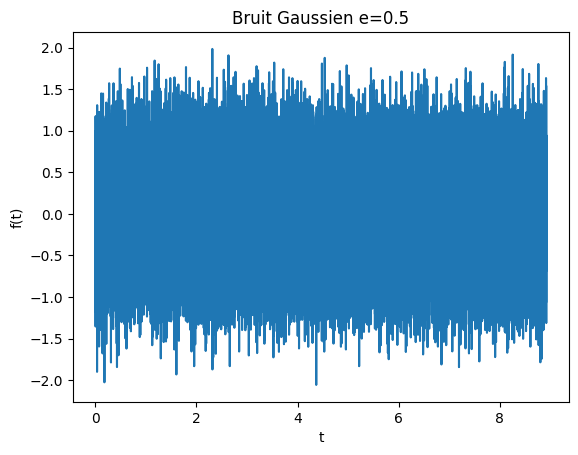

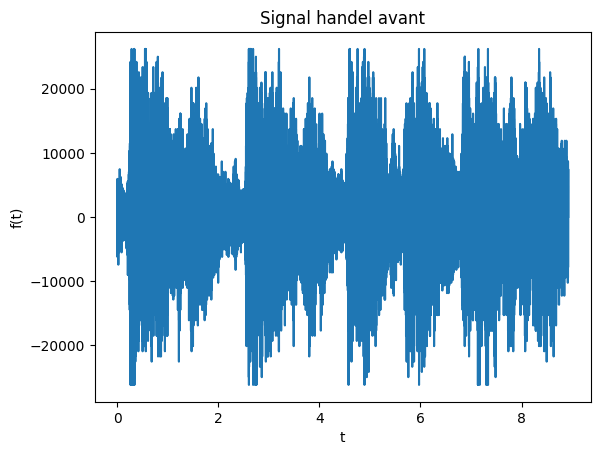

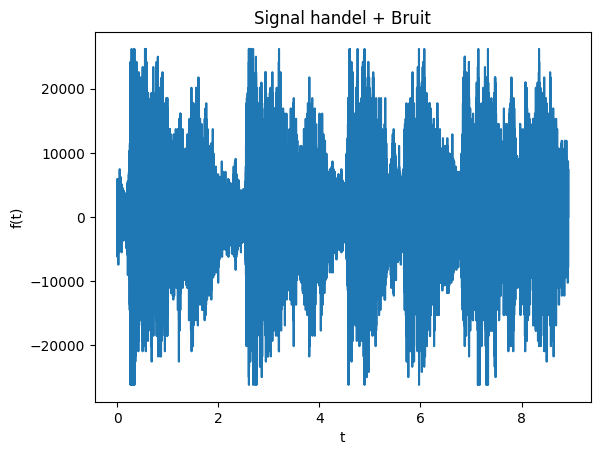

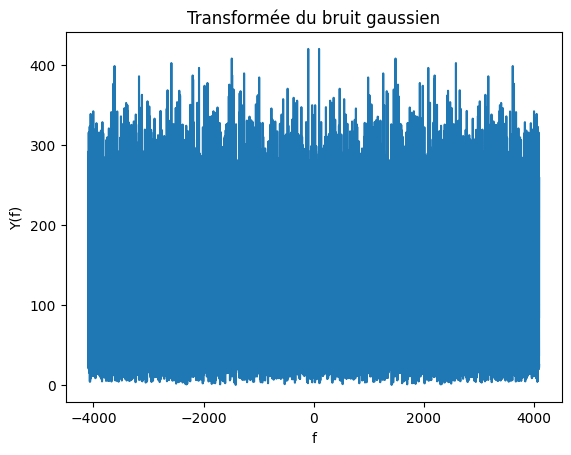

In [22]:
G = np.random.normal(0, 0.5, size=len(signal2))

plt.figure()
plt.plot(t, G)
plt.xlabel("t")
plt.ylabel("f(t)")
plt.title("Bruit Gaussien e=0.5")
plt.show()

plt.figure()
plt.plot(t, np.real(signal2))
plt.xlabel("t")
plt.ylabel("f(t)")
plt.title("Signal handel avant")
plt.show()

signalG = signal2 + G
signalG = np.clip(signalG, -32768, 32767)

wav.write('handelG.wav', fs2, signalG.astype(np.int16))

plt.figure()
plt.plot(t, np.real(signalG))
plt.xlabel("t")
plt.ylabel("f(t)")
plt.title("Signal handel + Bruit")
plt.show()

YG = np.fft.fftshift(np.fft.fft(G))

plt.figure()
plt.plot(f, np.abs(YG))
plt.xlabel("f")
plt.ylabel("Y(f)")
plt.title("Transformée du bruit gaussien")
plt.show()

8) Débruitez ce signal par le filtre précédent. Conclure.

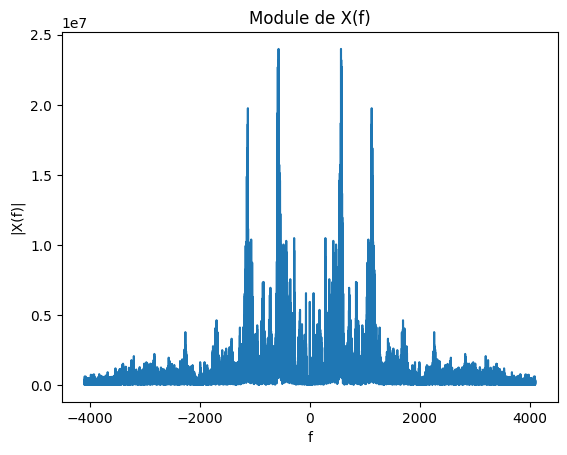

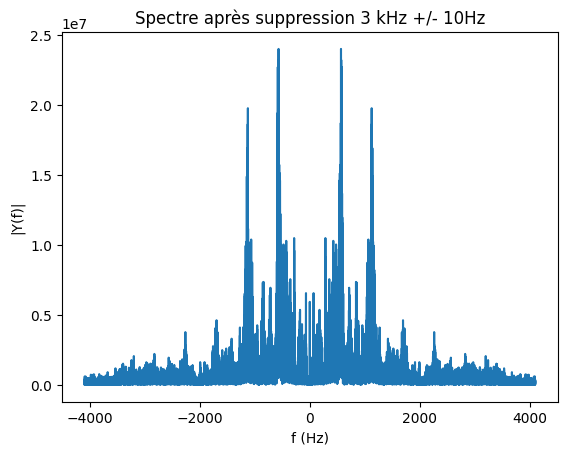

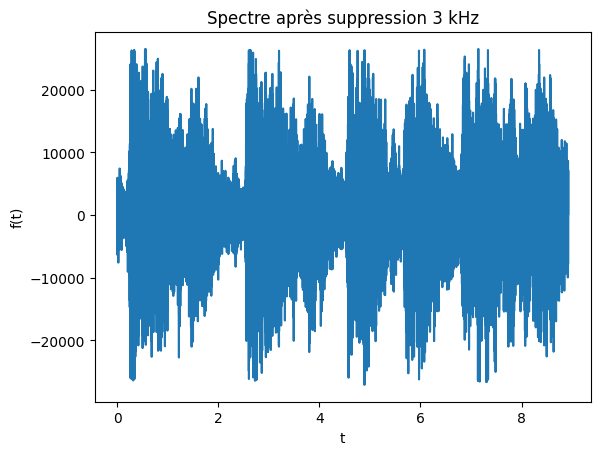

In [23]:
Ygau = np.fft.fftshift(np.fft.fft(signalG))
N = len(signalG)

plt.figure()
plt.plot(f, np.abs(Ygau))
plt.xlabel("f")
plt.ylabel("|X(f)|")
plt.title("Module de X(f)")
plt.show()

Ygf = Ygau * filtre
ygf = np.fft.ifft(np.fft.ifftshift(Ygf))

plt.figure()
plt.plot(f, np.abs(Ygf))
plt.xlabel("f (Hz)")
plt.ylabel("|Y(f)|")
plt.title("Spectre après suppression 3 kHz +/- 10Hz")
plt.show()

plt.figure()
plt.plot(t, np.real(ygf))
plt.xlabel("t")
plt.ylabel("f(t)")
plt.title("Spectre après suppression 3 kHz")
plt.show()

*Commentaires*: Le bruit gaussien ajouté est un bruit large bande ça transformée de Fourier montre bien qu'il affecte toutes les fréquences du signal. Le filtre utilisé, centré autour de 3 kHz, ne supprime qu’une petite portion du spectre. Ainsi, il ne permet pas de réduire efficacement le bruit. Le signal reste donc fortement bruité après filtrage. Un filtre fréquentiel marche pour un parasite fréquentiel mais pour un bruit aléatoire ce n'est pas la solution.

9) Générez 100 réalisations indépendantes du signal bruité par un bruit Gaussien et écoutez la moyenne temporelle de ces 100 signaux. Conclure.

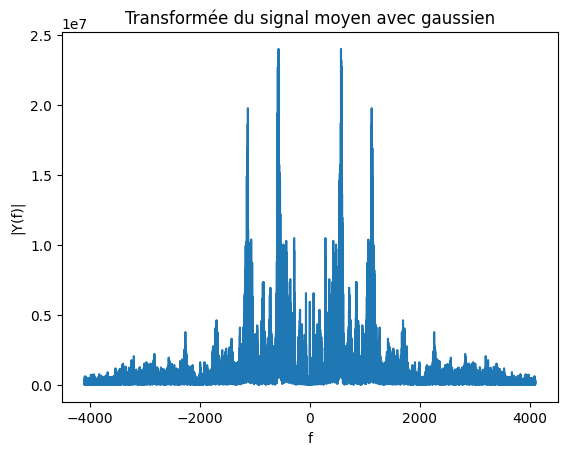

In [24]:
fs, signal = wav.read('handel.wav')
signal = signal.astype(float)


signals_bruites = []

for _ in range(100):
    bruit = np.random.normal(0, 0.5, size=len(signal))
    signals_bruites.append(signal + bruit)

signals_bruites = np.array(signals_bruites)
signal_moy = np.mean(signals_bruites, axis=0)

signal_moy = np.clip(signal_moy, -32768, 32767)

wav.write('handel_moyenne.wav', fs, signal_moy.astype(np.int16))

Ymoy = np.fft.fftshift(np.fft.fft(signal_moy))

plt.figure()
plt.plot(f, np.abs(Ymoy))
plt.xlabel("f")
plt.ylabel("|Y(f)|")
plt.title("Transformée du signal moyen avec gaussien")
plt.show()


*Commentaires*: La moyenne de plusieurs réalisations bruitées permet d’atténuer le bruit gaussien, car celui-ci est aléatoire et de moyenne nulle, tandis que le signal reste constant. Ainsi, le rapport signal/bruit est amélioré.

***

<h3><center>EXERCICE 4 : SYNTHÈSE D’UN SIGNAL SONORE</center></h3>


1) Rechercher (sur Wikipédia par exemple) les fréquences des notes de musique de base. Par exemple, la fréquence du "do" sur "3 octave dans la gamme des tempérés" est $261,63 Hz$.

*Commentaires (fréquences des notes de musique)*: Les fréquences des notes de musique sont définies selon la gamme tempérée.Les notes sont espacées logarithmiquement. Les fréquences suivent une progression géométrique (chaque octave correspond à un doublement de la fréquence).
Do (C4) → 261.63 Hz 
Ré (D4) → 293.66 Hz 
Mi (E4) → 329.63 Hz 
Fa (F4) → 349.23 Hz 
Sol (G4) → 392.00 Hz    
La (A4) → 440.00 Hz 
Si (B4) → 493.88 Hz 

2) Ecrire un programme qui joue les notes "FRERE -JAC-QUES" suivi de "DORMEZ-VOUS". On expliquera comment choisir la fréquence d’échantillonnage.

In [25]:
fe = 8000

def note(freq, duree):
    t = np.linspace(0, duree, int(fe*duree), endpoint=False)
    return np.sin(2*np.pi*freq*t)

# notes
C = 261.63
D = 293.66
E = 329.63
F = 349.23
G = 392.00
A = 440.00

d = 0.4

#Frère Jacques
part1 = np.concatenate([
    note(C,d), note(D,d), note(E,d), note(C,d)
])

# Dormez-vous
part2 = np.concatenate([
    note(E,d), note(F,d), note(G,2*d)
])

partie = np.concatenate([part1, part2])
musique = partie / np.max(np.abs(partie)) * 32767

wav.write("frere_jacques.wav", fe, musique.astype(np.int16))



*Commentaires (fréquence d’échantillonnage)*: il faut que fe>2*fmax, fmax ici est de 400Hz donc 8KHz est largement suffisant.

3) Lire la "musique" ainsi obtenue. Répétez-la 3 fois.

In [26]:
musique3 = np.tile(partie, 3)

musique3 = musique3 / np.max(np.abs(musique3)) * 32767

wav.write("frere_jacques3.wav", fe, musique3.astype(np.int16))

4) Question facultative. Ecrire un programme qui joue la berceuse précédente entièrement.

In [ ]:
# Sonnez les matines
part3 = np.concatenate([
    note(G,d), note(A,d), note(G,d), note(F,d),
    note(E,d), note(C,d)
])

# Ding ding dong
part4 = np.concatenate([
    note(C,d), note(G,d), note(C,2*d)
])


berceuse = np.concatenate([part1,part1, part2,part2, part3,part3, part4,part4])

berceuse = berceuse / np.max(np.abs(berceuse)) * 32767
berceuse = berceuse.astype(np.int16)

wav.write("frere_jacques_complet.wav", fe, berceuse)